# Basic setup

In [2]:
# Importing libraries

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
# from sklearn.preprocessing import StandardScaler

# Gaussian distribution

## Population

<Axes: ylabel='Count'>

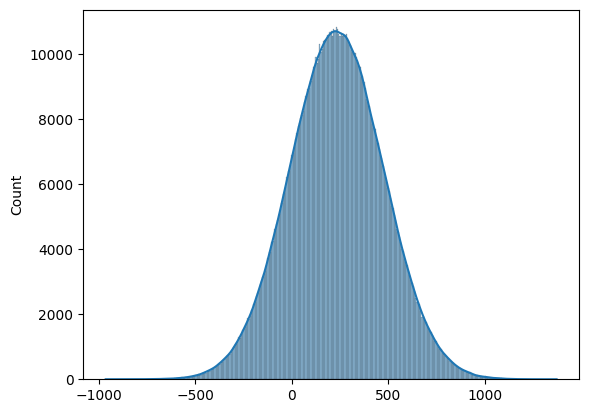

In [3]:
# Creating a population with normal distribution

rng = np.random.default_rng()
normal  =rng.normal(loc=232, scale=243, size=1000000)
sns.histplot(normal, kde=True)

In [4]:
# Calculating the mean and standard deviation manually

manual_mean = normal.sum() / len(normal)
print(f'Manual mean: {manual_mean:,.2f}')
manual_variance = float(np.sum((normal - manual_mean) ** 2) ) / len(normal)
print(f'Manual variance: {manual_variance:,.2f}')
manual_std = np.sqrt(manual_variance)
print(f'Manual std: {manual_std:,.2f}')


Manual mean: 232.13
Manual variance: 59,150.36
Manual std: 243.21


In [5]:
# Calculating the mean and standard deviation with formulas

normal_mean = normal.mean()
print(f'Normal mean: {normal_mean:,.2f}')
normal_variance = normal.var()
print(f'Normal variance: {normal_variance:,.2f}')
normal_std = normal.std()
print(f'Normal std: {normal_std:,.2f}')


Normal mean: 232.13
Normal variance: 59,150.36
Normal std: 243.21


## Standardization Z scores

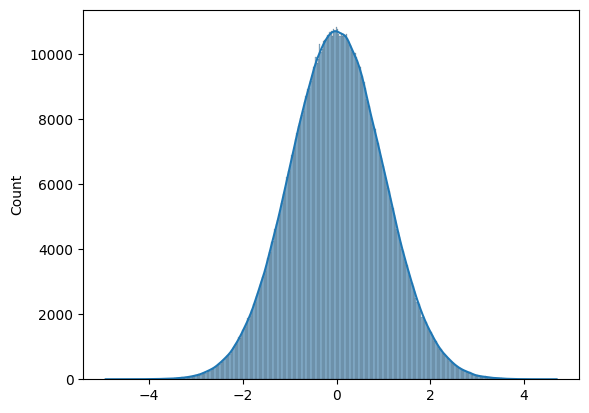

Mean of standardized data: 0.00


In [6]:
# Normalization
normal_normalized = (normal - normal_mean) / normal_std
sns.histplot(normal_normalized, kde=True)
plt.show()

print(f'Mean of standardized data: {normal_normalized.mean():,.2f}')

In [7]:
# Combining the two datasets: normal and normalized

all_normal = pd.DataFrame({'Normal': normal, 'Normal_normalized': normal_normalized})

all_normal.head()

,Normal,Normal_normalized
0,-165.477980,-1.634864
1,251.837931,0.081013
2,373.642967,0.581839
3,81.679082,-0.618629
4,-188.236243,-1.728439


## Sampling


Manual calculations:

Sample mean: 230.75
Sample variance: 61,075.13
Sample standard deviation: 247.13
Sample Standard Error of the Mean: 7.82

Formula calculations:

Sample mean: 230.75
Sample variance: 61,075.13
Sample standard deviation: 247.13
Sample Standard Error of the Mean: 7.82


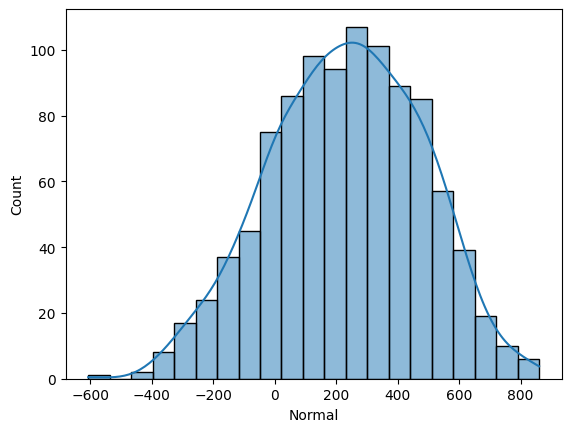

In [8]:
sample = all_normal['Normal'].sample(1000)
sns.histplot(sample, kde=True)

# Manual calculations
print('\nManual calculations:\n')
sample_mean = float(np.sum(sample)) / len(sample)
print(f'Sample mean: {sample_mean:,.2f}')

sample_variance = float(np.sum((sample - sample_mean)**2)) / (len(sample)-1)
print(f'Sample variance: {sample_variance:,.2f}')

sample_std = np.sqrt(sample_variance)
print(f'Sample standard deviation: {sample_std:,.2f}')

# Standard error
sample_sem = sample_std / np.sqrt(len(sample))
print(f'Sample Standard Error of the Mean: {sample_sem:,.2f}')

# Formula calculations
print('\nFormula calculations:\n')
for_sample_mean = sample.mean()
print(f'Sample mean: {for_sample_mean:,.2f}')

for_sample_variance = sample.var(ddof=1)
print(f'Sample variance: {for_sample_variance:,.2f}')

for_sample_std = np.std(sample, ddof=1)
print(f'Sample standard deviation: {for_sample_std:,.2f}')

for_sample_sem = stats.sem(sample)
print(f'Sample Standard Error of the Mean: {for_sample_sem:,.2f}')


Sample mean: 232.53


<Axes: ylabel='Count'>

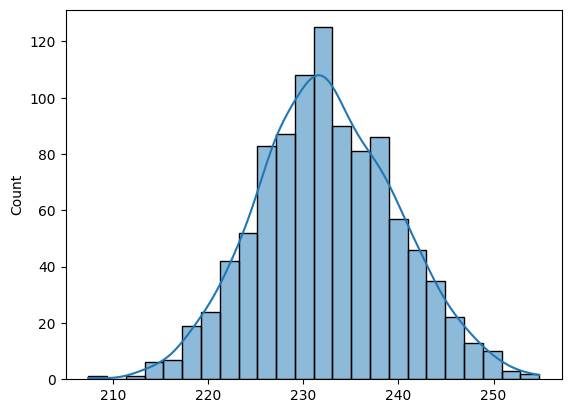

In [9]:
# Ongoing sampling

sample_means = []
for i in range(1000):
    sample_mean = all_normal['Normal'].sample(1000).mean()
    sample_means.append(sample_mean)

sample_means_np = np.array(sample_means)
print(f'Sample mean: {sample_means_np.mean():,.2f}')

sns.histplot(sample_means_np, kde=True)

<Axes: ylabel='Count'>

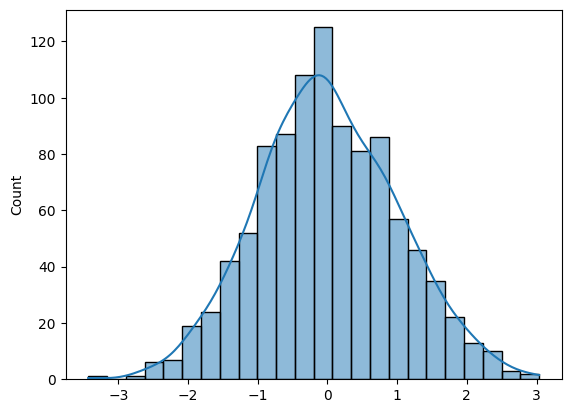

In [10]:
# Standardizing the sample means does not bring any specific value
standard_sample_means = stats.zscore(sample_means_np) #
# CDF
sns.histplot(standard_sample_means, kde=True, cumulative=False)

# Exponential distribution

<Axes: ylabel='Count'>

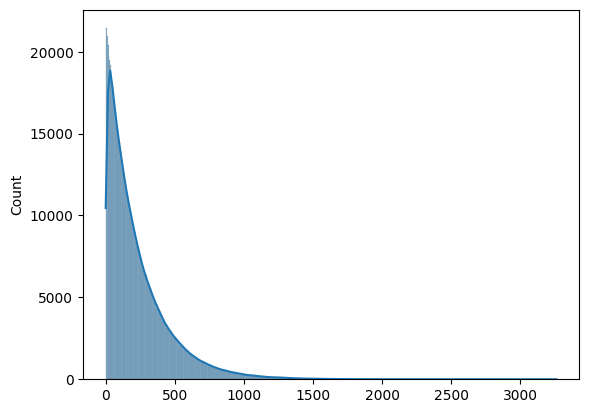

In [11]:
# Creating a population with exponential distribution

rng = np.random.default_rng()
expo = rng.exponential(scale=232, size=1000000)
sns.histplot(expo, kde=True)

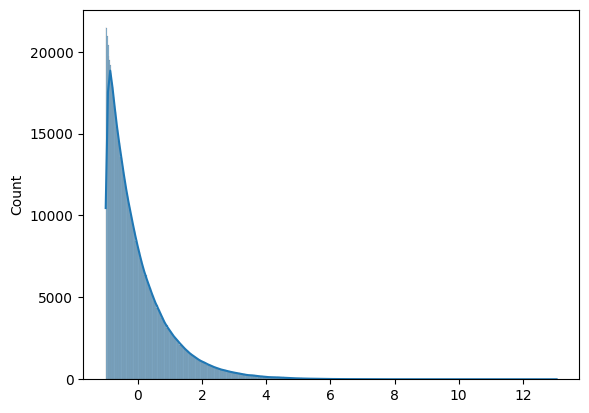

In [12]:
expo_zscore = stats.zscore(expo)
sns.histplot(expo_zscore, kde=True)

all_expo = pd.DataFrame({'Exponential': expo, 'Exponential_zscore': expo_zscore})

## Central Limit Theorem

<Axes: ylabel='Count'>

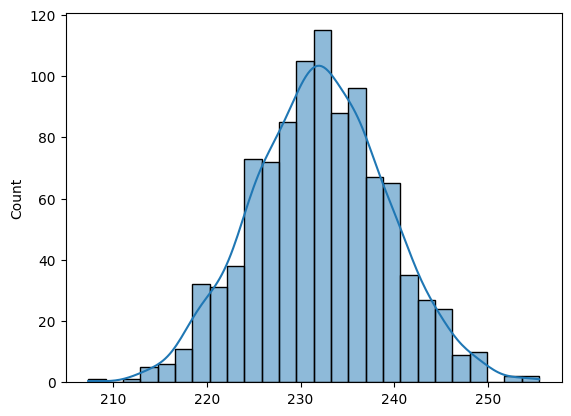

In [13]:
expo_means = []
for i in range(1000):
    expo_mean = all_expo['Exponential'].sample(1000).mean()
    expo_means.append(expo_mean)

sns.histplot(expo_means, kde=True)

# Hypothesis testing

In [14]:
# TODO 1. Power of a test
# TODO 2. Cohen distance

Sample mean: 230.75


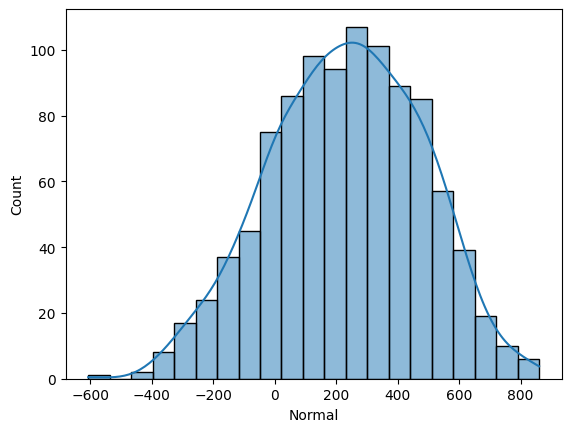

In [15]:
small_sample = all_normal['Normal'].sample(1000)
sns.histplot(sample, kde=True)
print(f'Sample mean: {sample.mean():,.2f}')

In [16]:
# Calculating the standard error

sample_sem = small_sample.std() / np.sqrt(len(small_sample))
print(f'The sample mean is {small_sample.mean():,.2f}')
print(f'The standard error of the mean is: {sample_sem:,.2f}')

The sample mean is 212.62
The standard error of the mean is: 7.74


In [17]:
# Confidence interval
# 1.96 is the 95% confidence interval (critical value)

margin_of_error = 1.96 * sample_sem
confidence_interval_upper = small_sample.mean() + margin_of_error
confidence_interval_lower = small_sample.mean() - margin_of_error
print(f'The confidence interval is between: {confidence_interval_lower:,.2f} and {confidence_interval_upper:,.2f}')

The confidence interval is between: 197.45 and 227.79


In [33]:
# Hypothesis testing

# Z statistic
hyp_mean = 219 #H0

z_statistic = (small_sample.mean() - hyp_mean) / sample_sem
p_value = stats.norm.sf(abs(z_statistic)) * 2

# print(f'The Z statistic is: {z_statistic:.2f}')
print(f'The sample mean is {z_statistic:.2f} standard errors away from the hypothesized mean (H0) which is {hyp_mean:,.2f}.')
print(f'If the true population mean is {hyp_mean:,.2f} (H0), then the probability of collecting a sample mean of {small_sample.mean():,.2f} from that population is {p_value:.2f}%')

The sample mean is -0.82 standard errors away from the hypothesized mean (H0) which is 219.00
If the true population mean is 219.00 (H0), then the probability of collecting a sample mean of 212.62 from that population is 0.41%


Note: If the Z statistic would be 1.96, then the p--value would be 5%